C:\Users\HP\AppData\Local\Temp\ipykernel_3052\2782472323.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
C:\Users\HP\AppData\Local\Temp\ipykernel_3052\2782472323.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time'].fillna(df['Time'].median(), inplace=True)


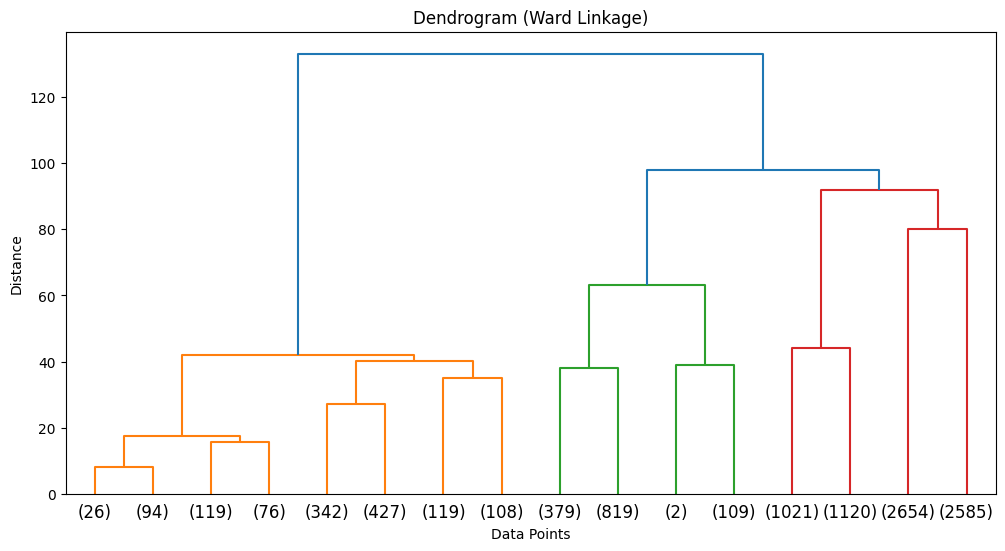

C:\Users\HP\AppData\Local\Temp\ipykernel_3052\2782472323.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_sample['Cluster'], palette='viridis')


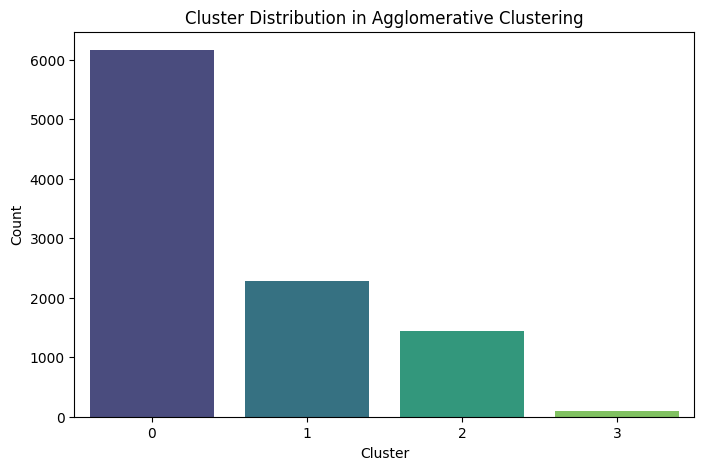

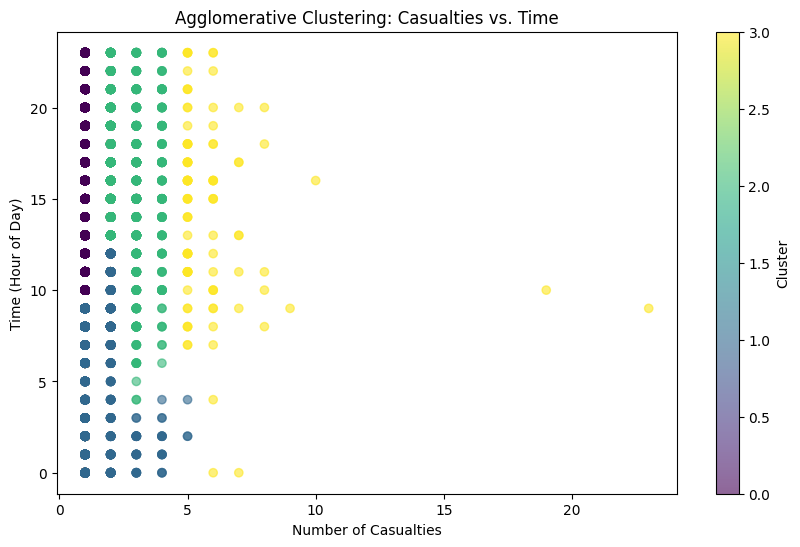


Cluster Summary:
          Number_of_Casualties       Time
Cluster                                 
0                    1.000000  15.985075
1                    1.276540   6.718218
2                    2.430152  16.394191
3                    5.970297  14.217822
Silhouette Score (Euclidean Distance): 0.47839784893303405
Adjusted Rand Index: 0.01893426983568335
       Number_of_Casualties  Time  Cluster
17531                     1  18.0        0
52517                     2   7.0        1
48036                     2  11.0        1
49690                     1  16.0        0
28058                     1   8.0        1


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Load dataset
df = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\RoadAccidentCurrent.xlsx")

# Convert 'Time' to numerical (hour of the day)
df['Time'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
df['Time'].fillna(df['Time'].median(), inplace=True)

# Select features for clustering
features = ['Number_of_Casualties', 'Time']
df_sample = df[features].dropna().sample(n=10000, random_state=42)  # Sample for performance

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

# Compute distance matrix using Ward linkage
# Replacing this with the dendrogram logic from the first code
dendrogram_features = ['Number_of_Casualties', 'Number_of_Vehicles', 'Time', 'Accident_Severity']
df_dendrogram = df[dendrogram_features].dropna().sample(n=10000, random_state=42)
X_dendrogram_scaled = scaler.fit_transform(df_dendrogram)
distance_matrix = linkage(X_dendrogram_scaled, method='ward')

# 1. Dendrogram for Optimal Clusters (Updated from the first code)
plt.figure(figsize=(12, 6))
dendrogram(distance_matrix, truncate_mode='level', p=3)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

# 2. Apply Agglomerative Clustering (Assuming Optimal K = 4)
optimal_k = 4
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
df_sample['Cluster'] = agg_clustering.fit_predict(X_scaled)

# 3. Histogram of Cluster Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=df_sample['Cluster'], palette='viridis')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Cluster Distribution in Agglomerative Clustering')
plt.show()

# 4. Scatter Plot of Clusters
plt.figure(figsize=(10, 6))
plt.scatter(df_sample['Number_of_Casualties'], df_sample['Time'], c=df_sample['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Number of Casualties')
plt.ylabel('Time (Hour of Day)')
plt.title('Agglomerative Clustering: Casualties vs. Time')
plt.colorbar(label='Cluster')
plt.show()

# 5. Cluster Analysis & Metrics
# Cluster summary
cluster_summary = df_sample.groupby('Cluster')[features].mean()
print("\nCluster Summary:\n", cluster_summary)

# Compute Silhouette Score
silhouette_avg = silhouette_score(X_scaled, df_sample['Cluster'], metric='euclidean')
print(f"Silhouette Score (Euclidean Distance): {silhouette_avg}")

# Adjusted Rand Index (ARI) if severity labels exist
if 'Accident_Severity' in df.columns:
    severity_labels = df.loc[df_sample.index, 'Accident_Severity'].astype('category').cat.codes
    ari = adjusted_rand_score(severity_labels, df_sample['Cluster'])
    print(f"Adjusted Rand Index: {ari}")

# 6. Display Sample Clustered Data
print(df_sample.head())